In [1]:
train_sets = [
    '../data/raw/sample_23.csv',
    '../data/processed/sample_23_znorm.parquet'
 ]
test_set = '../data/raw/sample_24.csv'

# Set to None to use full dataset
SAMPLE_SIZE = None
CLUSTERS_COUNT = 7
RANDOM_STATE = 42

# Runtime controls
PLOT_INDIVIDUAL_SERIES = False
MAX_SERIES_PER_CLUSTER_PLOT = 300
KSHAPE_MAX_ITER = 50

In [2]:
#%pip install tslearn
#%pip install matplotlib
#%pip install pandas

import numpy as np
import pandas as pd
from tslearn.clustering import KShape
from tslearn.utils import to_time_series_dataset
import matplotlib.pyplot as plt

In [3]:
from pathlib import Path

_DATA_CACHE = {}

def load_values(filepath):
    """Load ids and numeric matrix (rows x timesteps) from csv/parquet."""
    if filepath in _DATA_CACHE:
        return _DATA_CACHE[filepath]

    path = Path(filepath)
    if path.suffix.lower() == '.parquet':
        df = pd.read_parquet(path)
    else:
        df = pd.read_csv(path)

    ids = df.iloc[:, 0].to_numpy()
    headers = df.columns[1:].tolist()
    values = df.iloc[:, 1:].to_numpy(dtype=np.float32, copy=False)

    _DATA_CACHE[filepath] = (ids, headers, values)
    return ids, headers, values

def calculate_copy_paste(train_path, test_path):
    _, _, data_23 = load_values(train_path)
    _, _, data_24 = load_values(test_path)

    rows = min(data_23.shape[0], data_24.shape[0])
    cols = min(data_23.shape[1], data_24.shape[1])
    data_23 = data_23[:rows, :cols]
    data_24 = data_24[:rows, :cols]

    abs_diff = np.abs(data_23 - data_24)
    mae = float(abs_diff.mean())

    non_zero_mask = data_24 != 0
    if np.any(non_zero_mask):
        mape = float(np.abs((data_24[non_zero_mask] - data_23[non_zero_mask]) / data_24[non_zero_mask]).mean() * 100)
    else:
        mape = 0.0

    print(f"Aligned shape: {data_23.shape}")
    print(f"Mean Absolute Error (MAE): {mae:.4f} units")
    print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

for train_set in train_sets:
    print(f"Evaluating copy-paste strategy for: {train_set}")
    calculate_copy_paste(train_set, test_set)

Evaluating copy-paste strategy for: ../data/raw/sample_23.csv
Aligned shape: (17547, 365)
Mean Absolute Error (MAE): 3.8561 units
Mean Absolute Percentage Error (MAPE): 323.64%
Evaluating copy-paste strategy for: ../data/processed/sample_23_znorm.parquet
Aligned shape: (17547, 365)
Mean Absolute Error (MAE): 9.1154 units
Mean Absolute Percentage Error (MAPE): 266.84%


In [ ]:
def make_output_dir():
    candidates = [Path('outputs/kshape'), Path('notebooks/outputs/kshape')]
    for base in candidates:
        if base.parent.exists():
            base.mkdir(parents=True, exist_ok=True)
            return base
    fallback = Path('outputs/kshape')
    fallback.mkdir(parents=True, exist_ok=True)
    return fallback

def generate_clustering(train_values):
    if SAMPLE_SIZE is not None:
        data_array = np.asarray(train_values[:SAMPLE_SIZE], dtype=np.float32)
    else:
        data_array = np.asarray(train_values, dtype=np.float32)

    formatted_data = to_time_series_dataset(data_array)

    ks = KShape(
        n_clusters=CLUSTERS_COUNT,
        n_init=1,
        max_iter=KSHAPE_MAX_ITER,
        random_state=RANDOM_STATE
    )
    ks.fit(formatted_data)

    print(f"cluster_centers shape: {ks.cluster_centers_.shape}")
    print(f"inertia: {ks.inertia_:.4f}")
    print(f"samples clustered: {formatted_data.shape[0]}")

    return ks, formatted_data

output_dir = make_output_dir()
clusterings = []
for train_set in train_sets:
    print(f"Generating clustering for: {train_set}")
    ids, _, train_values = load_values(train_set)
    clustering, formatted_data = generate_clustering(train_values)

    if SAMPLE_SIZE is not None:
        ids_for_export = ids[:SAMPLE_SIZE]
    else:
        ids_for_export = ids

    export_df = pd.DataFrame({
        'ID': ids_for_export,
        'cluster': clustering.labels_
    })

    export_name = f"kshape_cluster_labels_{Path(train_set).stem}.csv"
    export_path = output_dir / export_name
    export_df.to_csv(export_path, index=False)
    # if we want to export parquet instead of csv to save space
    # export_df.to_parquet(export_path.with_suffix('.parquet'), index=False)

    print(f"Saved: {export_path}")

    clusterings.append((train_set, clustering, formatted_data))

Generating clustering for: ../data/raw/sample_23.csv
cluster_centers shape: (7, 365, 1)
inertia: 0.2690
samples clustered: 17547
Saved: outputs/kshape/kshape_cluster_labels_sample_23.csv
Generating clustering for: ../data/processed/sample_23_znorm.parquet
cluster_centers shape: (7, 365, 1)
inertia: 0.2893
samples clustered: 17547
Saved: outputs/kshape/kshape_cluster_labels_sample_23_znorm.csv


Plotting cluster panels for: ../data/raw/sample_23.csv


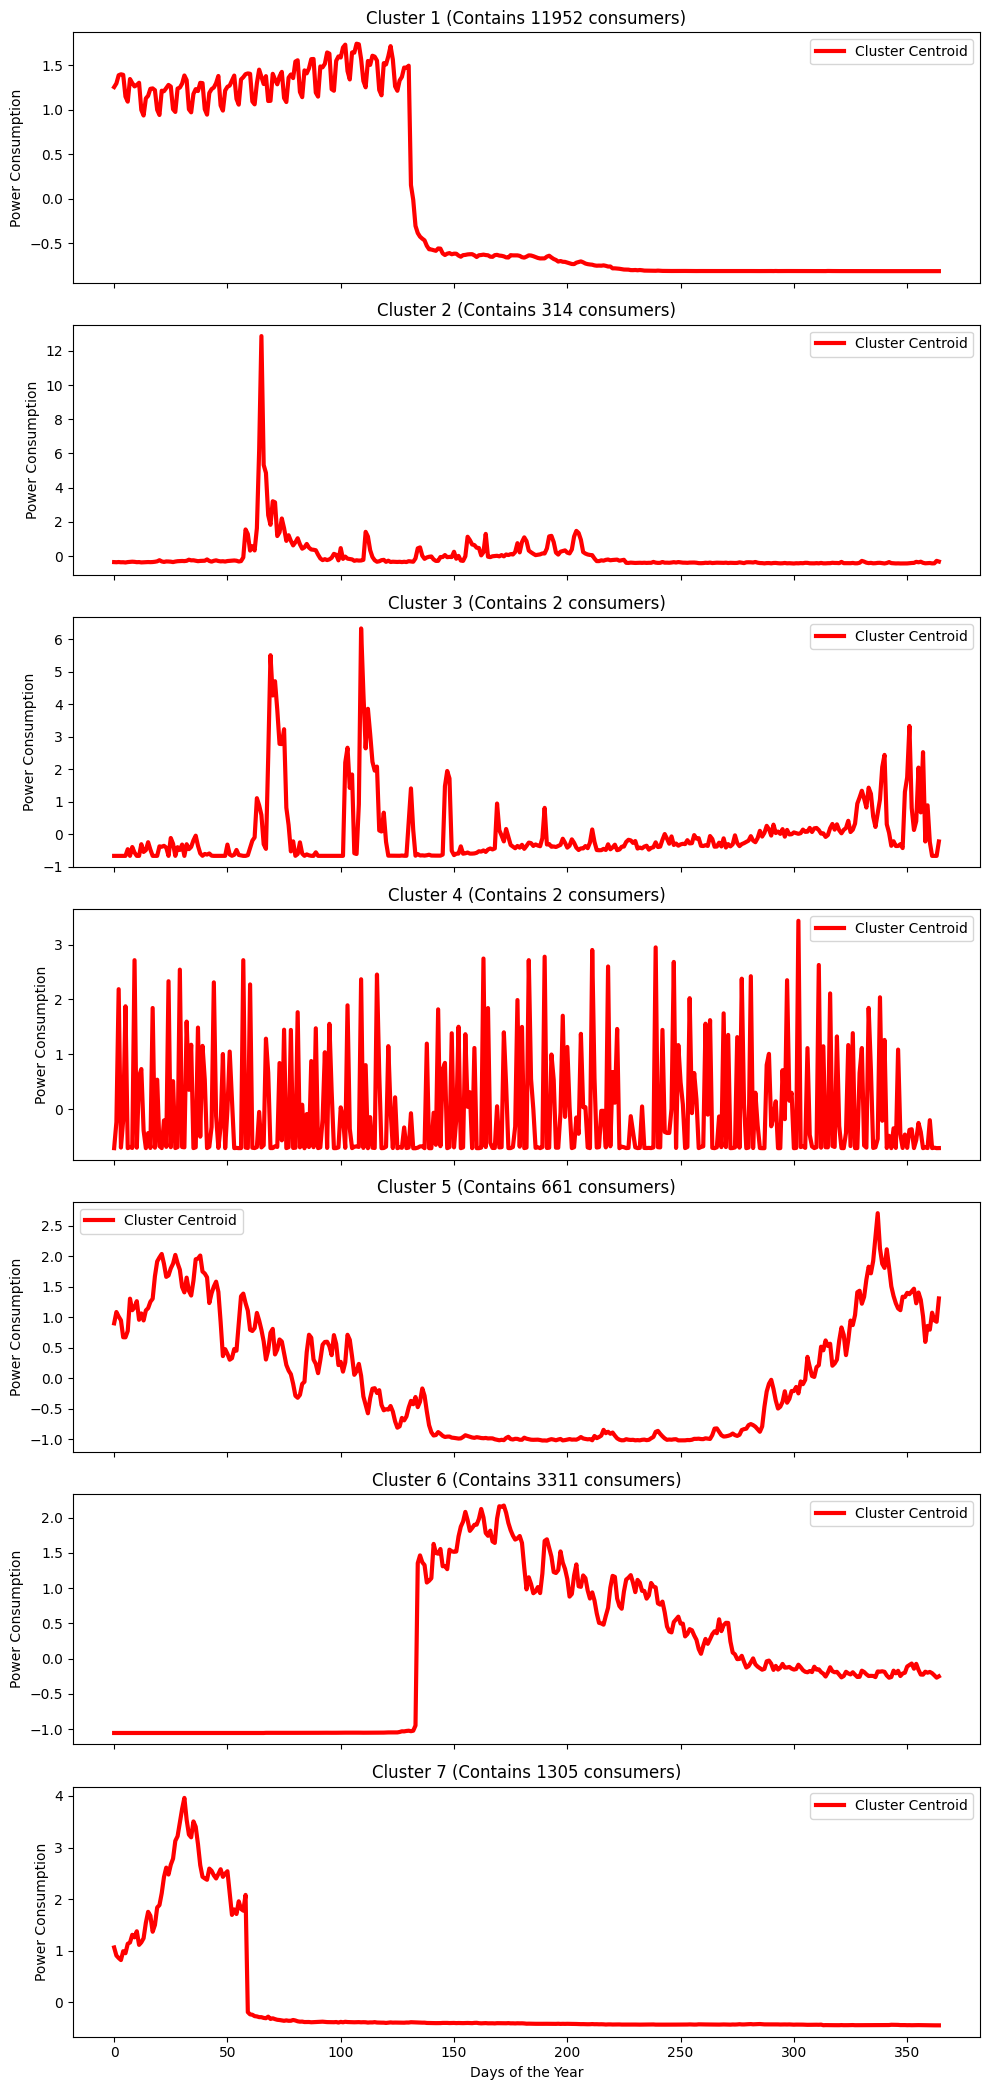

Plotting cluster panels for: ../data/processed/sample_23_znorm.parquet


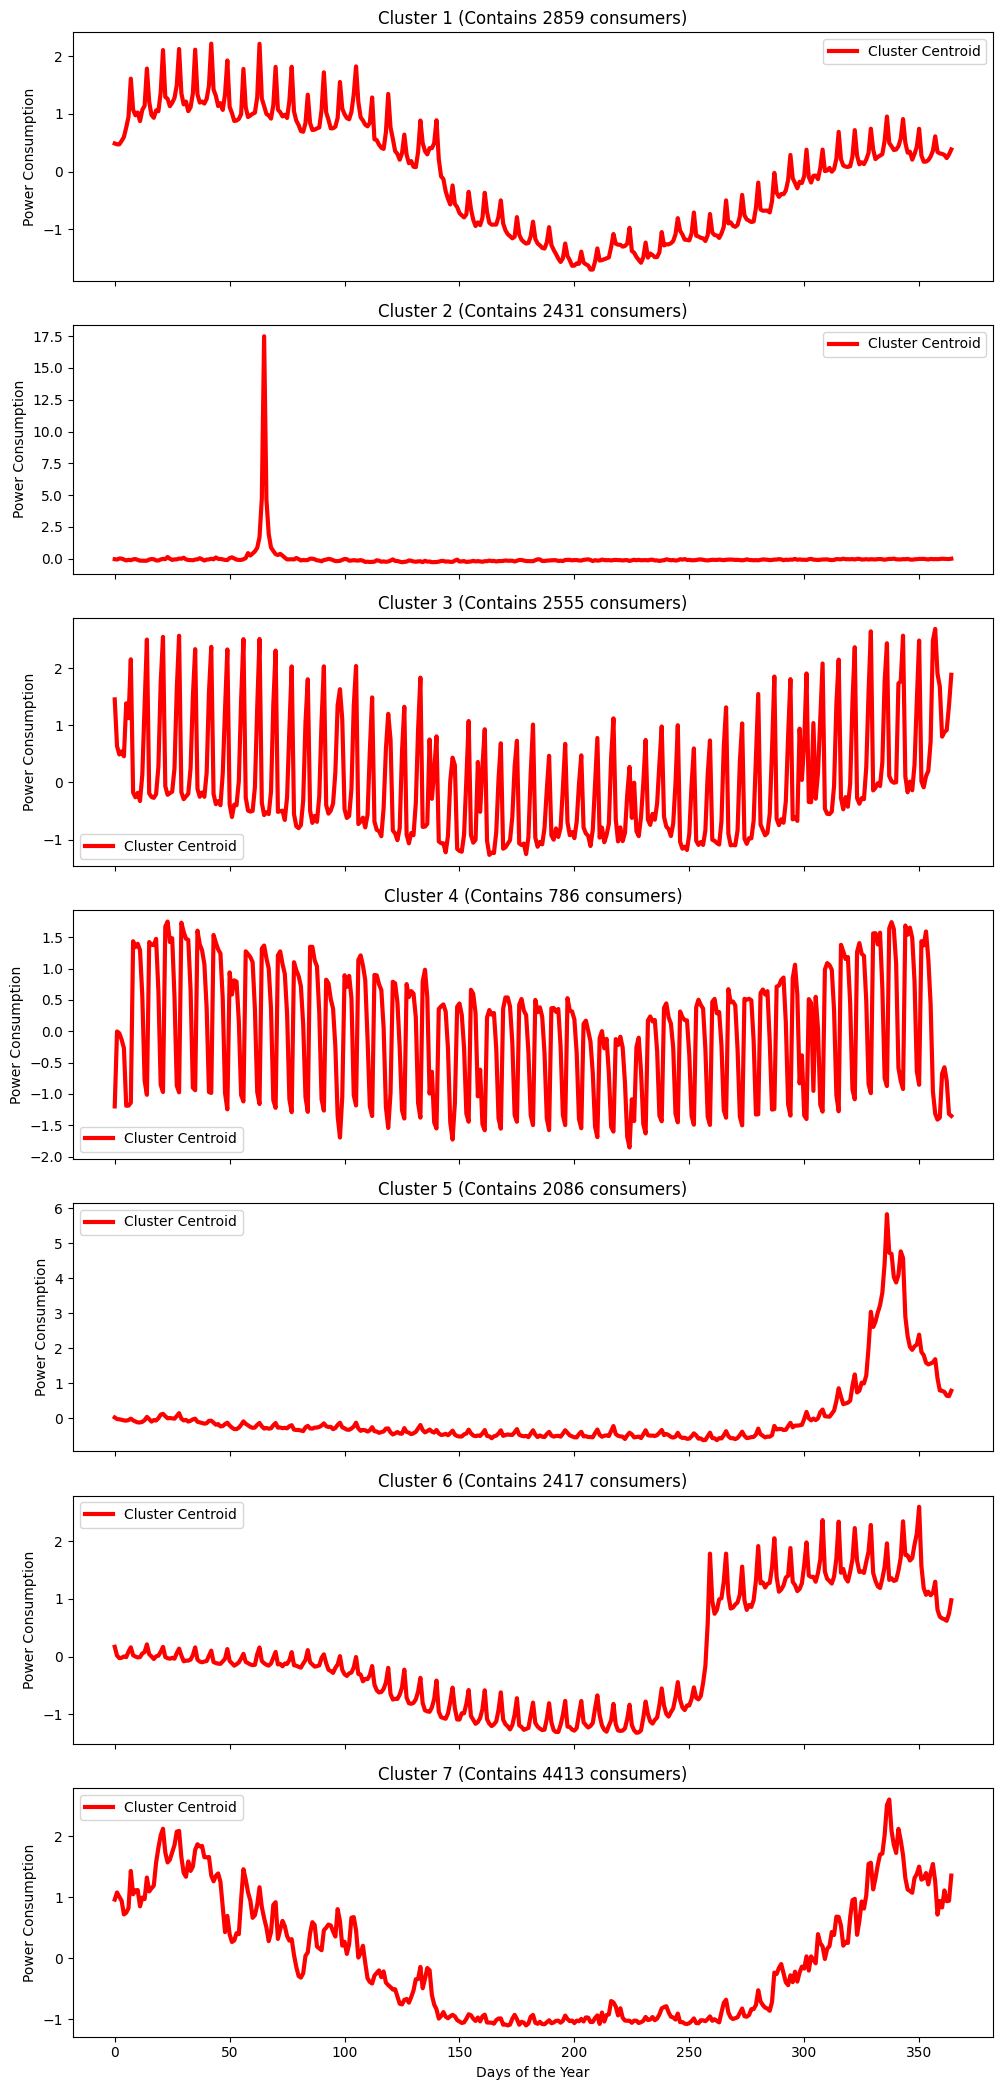

In [5]:
import matplotlib.pyplot as plt

def print_clusters(ks, formatted_data, plot_individual=PLOT_INDIVIDUAL_SERIES, max_series_per_cluster=MAX_SERIES_PER_CLUSTER_PLOT):
    labels = ks.labels_
    centers = ks.cluster_centers_
    optimal_k = len(centers)

    fig, axes = plt.subplots(optimal_k, 1, figsize=(10, 3 * optimal_k), sharex=True)
    if optimal_k == 1:
        axes = [axes]

    for i in range(optimal_k):
        cluster_data = formatted_data[labels == i]

        if plot_individual and len(cluster_data) > 0:
            sample_n = min(max_series_per_cluster, len(cluster_data))
            idx = np.random.choice(len(cluster_data), size=sample_n, replace=False)
            for series in cluster_data[idx]:
                axes[i].plot(series.ravel(), color='gray', alpha=0.08)

        axes[i].plot(centers[i].ravel(), color='red', linewidth=3, label='Cluster Centroid')
        axes[i].set_title(f"Cluster {i+1} (Contains {len(cluster_data)} consumers)")
        axes[i].set_ylabel("Power Consumption")
        axes[i].legend()

    plt.xlabel("Days of the Year")
    plt.tight_layout()
    plt.show()

for train_set, clustering, formatted_data in clusterings:
    print(f"Plotting cluster panels for: {train_set}")
    print_clusters(clustering, formatted_data)

Plotting overlay clusters for: ../data/raw/sample_23.csv


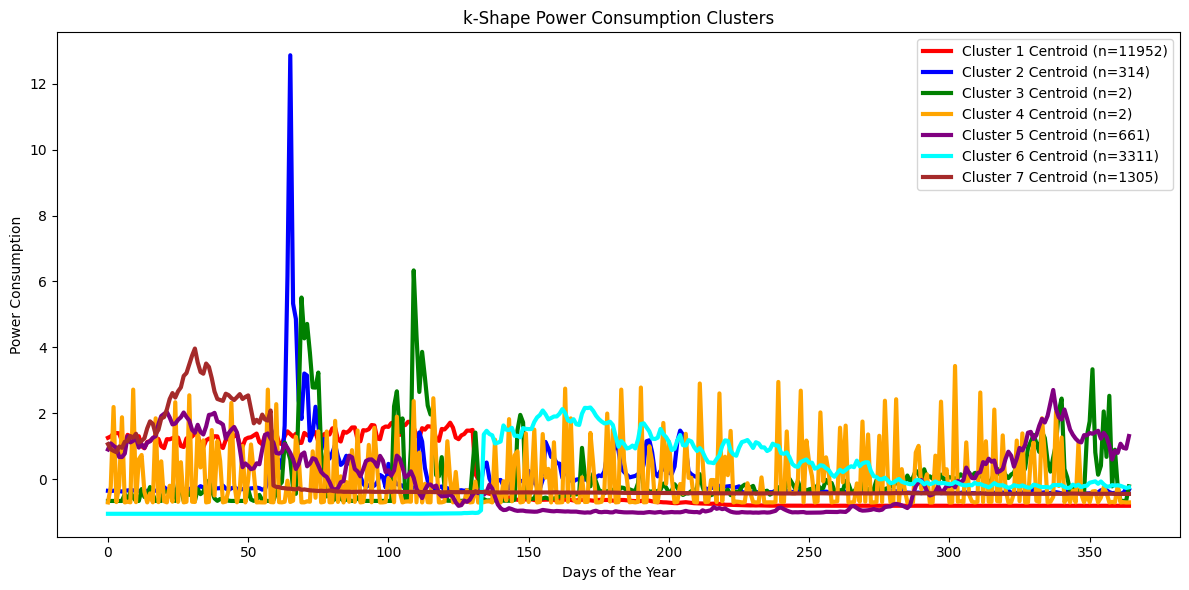

Plotting overlay clusters for: ../data/processed/sample_23_znorm.parquet


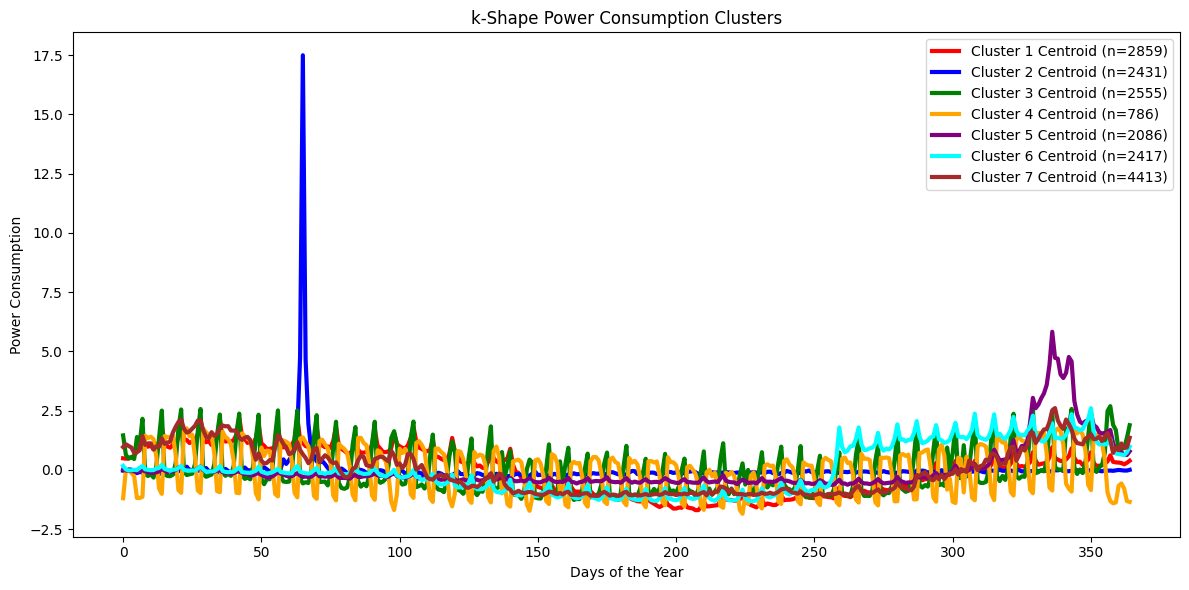

In [6]:
import matplotlib.pyplot as plt

def print_all_clusters(ks, formatted_data, plot_individual=PLOT_INDIVIDUAL_SERIES, max_series_per_cluster=MAX_SERIES_PER_CLUSTER_PLOT):
    labels = ks.labels_
    centers = ks.cluster_centers_
    optimal_k = len(centers)

    colors = ['red', 'blue', 'green', 'orange', 'purple', 'cyan', 'brown', 'olive']

    plt.figure(figsize=(12, 6))

    for i in range(optimal_k):
        cluster_data = formatted_data[labels == i]
        cluster_color = colors[i % len(colors)]

        if plot_individual and len(cluster_data) > 0:
            sample_n = min(max_series_per_cluster, len(cluster_data))
            idx = np.random.choice(len(cluster_data), size=sample_n, replace=False)
            for series in cluster_data[idx]:
                plt.plot(series.ravel(), color=cluster_color, alpha=0.04)

        plt.plot(
            centers[i].ravel(),
            color=cluster_color,
            linewidth=3,
            label=f'Cluster {i+1} Centroid (n={len(cluster_data)})'
        )

    plt.title('k-Shape Power Consumption Clusters')
    plt.xlabel('Days of the Year')
    plt.ylabel('Power Consumption')
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

for train_set, clustering, formatted_data in clusterings:
    print(f"Plotting overlay clusters for: {train_set}")
    print_all_clusters(clustering, formatted_data)